In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error 

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [5]:
df.Gender = le.fit_transform(df[['Gender']])

In [6]:
df.head()

,Gender,Height,Weight
0,1,73.847017,241.893563
1,1,68.781904,162.310473
2,1,74.110105,212.740856
3,1,71.730978,220.042470
4,1,69.881796,206.349801


In [7]:
df.tail()

,Gender,Height,Weight
8550,0,60.483946,110.565497
8551,0,63.423372,129.921671
8552,0,65.584057,155.942671
8553,0,67.429971,151.678405
8554,0,60.921791,131.253738


# Go Ahead

# EDA

In [8]:
df.describe()

,Gender,Height,Weight
count,8555.000000,8555.000000,8555.000000
mean,0.584454,66.809925,165.632735
std,0.492845,3.851454,32.043922
min,0.000000,54.616858,65.780000
25%,0.000000,63.957684,139.876803
50%,1.000000,66.985923,168.521567
75%,1.000000,69.604427,190.666305
max,1.000000,80.450000,269.989698


In [9]:
df.isnull().sum()

Gender    0
Height    0
Weight    0
dtype: int64

In [10]:
df.isnull().mean() * 100

Gender    0.0
Height    0.0
Weight    0.0
dtype: float64

In [11]:
df.isnull()

,Gender,Height,Weight
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
8550,False,False,False
8551,False,False,False
8552,False,False,False
8553,False,False,False


Text(0.5, 1.0, 'Weight - Height')

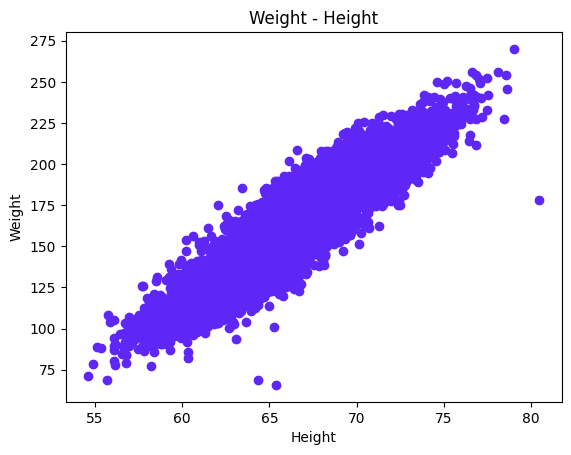

In [12]:
plt.scatter(df['Height'] , df['Weight'], color='#5E27F5', marker='o')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Weight - Height')

# Least Squared Linear Regression

In [13]:
x = df.drop(['Weight'], axis=1)

In [14]:
x.head()

,Gender,Height
0,1,73.847017
1,1,68.781904
2,1,74.110105
3,1,71.730978
4,1,69.881796


In [15]:
y = df[['Weight']]
y.head()

,Weight
0,241.893563
1,162.310473
2,212.740856
3,220.042470
4,206.349801


In [16]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.30, random_state=0)

In [17]:
xtrain.shape

(5988, 2)

In [18]:
xtest.shape

(2567, 2)

In [22]:
lin_reg  = LinearRegression() 
lin_reg .fit(xtrain, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred_lr = lin_reg.predict(xtest)

In [25]:
y_pred_lr 

array([[156.20235428],
       [184.93442898],
       [148.42945323],
       ...,
       [159.2442037 ],
       [166.96403181],
       [136.95529212]], shape=(2567, 1))

In [26]:
mse_lr = mean_squared_error(ytest, y_pred_lr)
mse_lr

102.30154155088867

In [27]:
rmse_lr = np.sqrt(mse_lr)
rmse_lr

np.float64(10.114422452660788)

In [28]:
r2_lr_train = lin_reg.score(xtrain, ytrain)
r2_lr_train

0.8988118427483529

In [29]:
r2_lr_test = lin_reg.score(xtest, ytest)
r2_lr_test

0.9025307579174772

# Regression Problem

In [30]:
from sklearn.neighbors import KNeighborsRegressor

In [31]:
X = df[['Gender', 'Height']]
y = df['Weight']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [33]:
# Create KNN Regressor model
knn = KNeighborsRegressor(n_neighbors=9)

In [34]:
knn.fit(X_train, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [35]:
# Predictions
y_pred_knn = knn.predict(X_test)
y_pred_knn

array([155.85693809, 189.24803171, 151.58452406, ..., 160.3033579 ,
       175.09523221, 135.22070614], shape=(2567,))

In [36]:
mse_knn = mean_squared_error(y_test, y_pred_knn)
mse_knn

117.47702367834276

In [37]:
rmse_knn = np.sqrt(mse_knn)
rmse_knn

np.float64(10.838681823835532)

In [38]:
r2_knn_train = knn.score(X_train, y_train)
r2_knn_train

0.9097752461678982

In [39]:
r2_knn_test = knn.score(X_test, y_test)
r2_knn_test

0.8880721024683407

# Comparison of Linear Rgeression and KNN Regressor

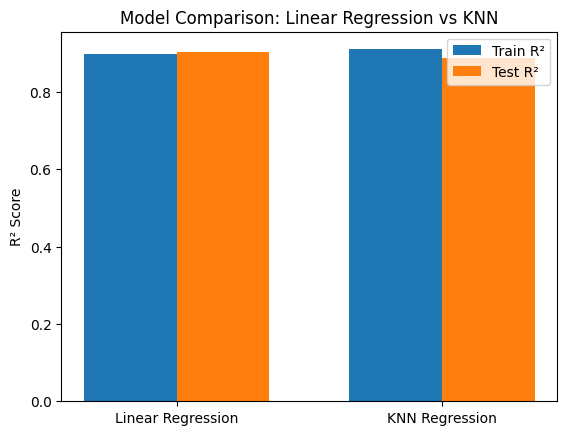

In [40]:
#plot
# Compare R² Scores
models = ['Linear Regression', 'KNN Regression']
train_scores = [r2_lr_train, r2_knn_train]
test_scores = [r2_lr_test, r2_knn_test]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, train_scores, width, label='Train R²')
plt.bar(x + width/2, test_scores, width, label='Test R²')

plt.xticks(x, models)
plt.ylabel("R² Score")
plt.title("Model Comparison: Linear Regression vs KNN")
plt.legend()
plt.show()

# MSE plot

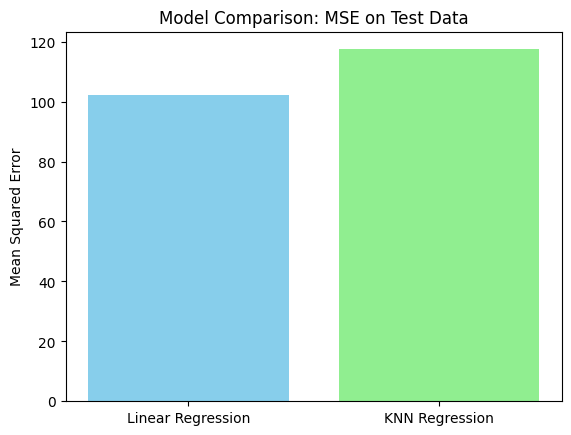

In [41]:
models = ['Linear Regression', 'KNN Regression']
mse_scores = [mse_lr, mse_knn]

plt.bar(models, mse_scores, color=['skyblue', 'lightgreen'])
plt.ylabel("Mean Squared Error")
plt.title("Model Comparison: MSE on Test Data")
plt.show()

# Classification Problem

In [63]:
data = pd.read_csv("weight-height.csv")

In [68]:
df.Gender = le.fit_transform(df[['Gender']])

In [69]:
df.head()

,Gender,Height,Weight
0,1,73.847017,241.893563
1,1,68.781904,162.310473
2,1,74.110105,212.740856
3,1,71.730978,220.042470
4,1,69.881796,206.349801


In [70]:
X = data[['Height', 'Weight']]
y = data['Gender']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [72]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [73]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [77]:
y_pred_knn  = knn.predict(X_test)
y_pred_knn 

array(['Male', 'Male', 'Female', ..., 'Male', 'Male', 'Female'],
      shape=(2567,), dtype=object)

In [78]:
acc_knn  = accuracy_score(y_test, y_pred_knn)
print("Accuracy of KNN Classifier:", acc_knn )

Accuracy of KNN Classifier: 0.9068952084144917


# Logistic Regrassion

In [80]:
from sklearn.linear_model import LogisticRegression

In [81]:
log_reg = LogisticRegression()

In [82]:
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [83]:
y_pred_log = log_reg.predict(X_test)
y_pred_log

array(['Male', 'Male', 'Female', ..., 'Male', 'Male', 'Female'],
      shape=(2567,), dtype=object)

In [84]:
acc_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", acc_log)

Logistic Regression Accuracy: 0.9107908063887806


# Comparison of Logistic Rgeression and KNN Classifier

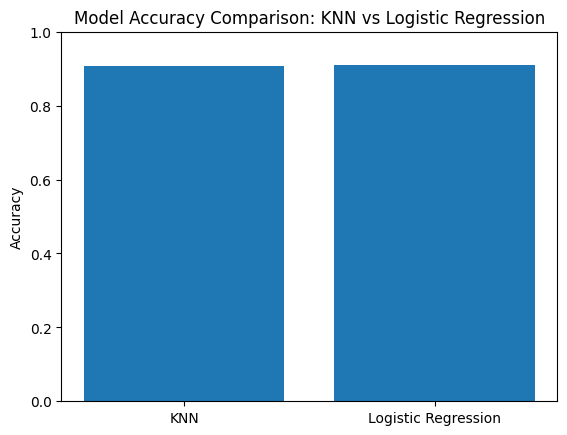

In [87]:
#plot
models = ['KNN', 'Logistic Regression']
accuracies = [acc_knn, acc_log]

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison: KNN vs Logistic Regression")
plt.ylim(0, 1)  # keep accuracy between 0 and 1
plt.show()